In [1]:
import pandas as pd, numpy as np

## Measured data

In [15]:
measured_path = r'Calibration\Profiler_modem_PFL_Step.dat' # r'Calibration\Profiler_modem_SondeHourly.dat'
measured_df = pd.read_csv(measured_path, delimiter=',', header=0, skiprows=[0, 2, 3], low_memory=False)
measured_df["TIMESTAMP"] = pd.to_datetime(measured_df["TIMESTAMP"])
measured_df["temperature"] = pd.to_numeric(measured_df["sensorParms(1)"], errors='coerce')
measured_df["depth"] = pd.to_numeric(measured_df["sensorParms(9)"], errors='coerce')
measured_df = measured_df[["TIMESTAMP", "temperature", "depth"]]
# interpolate missing values in the measured data
df_interpolated = measured_df.interpolate(method='linear', limit_direction='both')
# Get data for the year 2024
measured_2024 = df_interpolated[df_interpolated["TIMESTAMP"].dt.year == 2024].reset_index(drop=True)

In [24]:
df = (measured_2024.sort_values("TIMESTAMP").reset_index(drop=True))
new_profile = ((df["depth"] < 1.5) & (df["depth"].shift(1) > 5))

In [26]:
new_profile, new_profile.cumsum()

(0        False
 1        False
 2        False
 3        False
 4        False
          ...  
 21020    False
 21021    False
 21022    False
 21023    False
 21024    False
 Name: depth, Length: 21025, dtype: bool,
 0          0
 1          0
 2          0
 3          0
 4          0
         ... 
 21020    419
 21021    419
 21022    419
 21023    419
 21024    419
 Name: depth, Length: 21025, dtype: int32)

In [23]:
df

,TIMESTAMP,temperature,depth
0,2024-04-19 14:37:44,3.2860,0.943
1,2024-04-19 14:39:17,3.2780,2.091
2,2024-04-19 14:40:50,3.2665,3.091
3,2024-04-19 14:42:22,3.2550,4.090
4,2024-04-19 14:43:54,3.2540,5.095
...,...,...,...
21020,2024-11-15 13:14:42,6.8010,46.037
21021,2024-11-15 13:16:19,6.7980,46.906
21022,2024-11-15 13:17:57,6.7930,48.025
21023,2024-11-15 13:19:35,6.7930,49.018


In [21]:
measured_2024.head(60)

,TIMESTAMP,temperature,depth
0,2024-04-19 14:37:44,3.2860,0.943
1,2024-04-19 14:39:17,3.2780,2.091
2,2024-04-19 14:40:50,3.2665,3.091
3,2024-04-19 14:42:22,3.2550,4.090
4,2024-04-19 14:43:54,3.2540,5.095
5,2024-04-19 14:45:26,3.2500,6.022
6,2024-04-19 14:46:59,3.2290,7.088
7,2024-04-19 14:48:32,3.2390,8.032
8,2024-04-19 14:50:05,3.2460,9.046
9,2024-04-19 14:51:38,3.2540,10.072


<Axes: title={'center': 'Measured Depth Over Time'}, xlabel='Timestamp', ylabel='Depth (m)'>

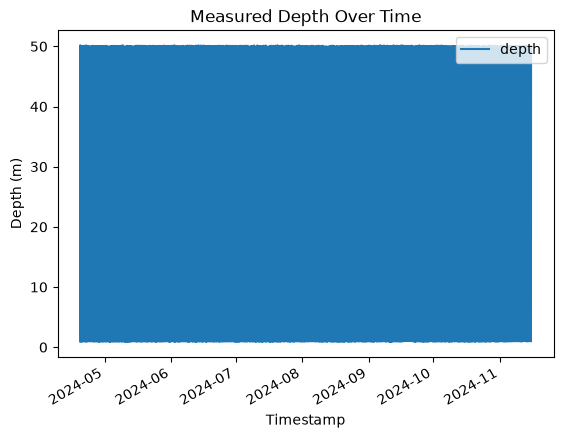

In [17]:
measured_2024.plot(x="TIMESTAMP", y="depth", title="Measured Depth Over Time", ylabel="Depth (m)", xlabel="Timestamp")

In [4]:
print(
    measured_df["depth"]
    .diff()
    .describe()
)



count    88982.000000
mean         0.000553
std          7.604703
min        -80.102000
25%          0.965000
50%          0.998000
75%          1.032000
max         58.753000
Name: depth, dtype: float64


In [5]:
print(
    measured_df.loc[
        measured_df["depth"].diff() < 0,
        ["TIMESTAMP", "temperature", "depth"]
    ].head(20)
)

               TIMESTAMP  temperature   depth
64   2020-06-10 00:01:59       10.598   0.940
137  2020-06-11 00:01:59       13.124   0.912
210  2020-06-11 12:01:55       13.237   0.922
284  2020-06-12 00:01:58       13.156   0.908
357  2020-06-12 02:02:46        4.495  72.581
358  2020-06-12 12:01:54       13.496   0.942
430  2020-06-13 00:01:58       15.131   0.899
503  2020-06-13 12:01:55       14.789   0.893
576  2020-06-14 00:01:58       16.163   0.903
650  2020-06-14 12:01:56       13.702   2.904
651  2020-06-14 12:03:30       14.826   1.872
719  2020-06-15 00:02:00       16.770   0.891
792  2020-06-15 12:01:53       16.976   0.894
870  2020-06-16 00:01:54       17.530   0.966
941  2020-06-16 12:01:53       17.955   0.902
1012 2020-06-17 00:01:54       18.278   0.967
1086 2020-06-17 12:01:53       18.800   0.900
1158 2020-06-18 00:01:59       18.578   0.870
1232 2020-06-18 12:01:54       19.135   0.919
1285 2020-06-18 13:26:24       29.080   9.670


In [61]:
target_depths = [2, 10, 30, 50]
df = measured_df.copy()
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])
df = df.sort_values("TIMESTAMP").reset_index(drop=True)
# Xác định profile mới khi depth giảm xuống
df["profile"] = (df["depth"].diff() < 0).cumsum()

In [ ]:
df

Index(['TIMESTAMP', 'temperature', 'depth'], dtype='str')
(88983, 3)
            TIMESTAMP  temperature  depth
0 2020-06-09 15:14:06       11.428  0.912
1 2020-06-09 15:15:39       10.806  2.134
2 2020-06-09 15:17:11       10.649  3.140
3 2020-06-09 15:18:43       10.375  4.122
4 2020-06-09 15:20:15       10.043  5.107


In [ ]:
df_minutes = measured_df.resample('min', on='TIMESTAMP').mean().reset_index()
# Interpolate missing values using linear interpolation
df_interpolated = df_minutes.interpolate(method='linear', limit_direction='both')
df_hourly = df_interpolated.resample('h', on='TIMESTAMP').mean().reset_index()
# Get data for the year 2024
measured_2024 = df_hourly[df_hourly["TIMESTAMP"].dt.year == 2024].set_index("TIMESTAMP")

In [49]:
measured_2024

,temperature,depth
TIMESTAMP,,
2024-01-01 00:00:00,5.091867,35.252376
2024-01-01 01:00:00,5.091180,35.239331
2024-01-01 02:00:00,5.090494,35.226287
2024-01-01 03:00:00,5.089807,35.213242
2024-01-01 04:00:00,5.089120,35.200197
...,...,...
2024-12-31 19:00:00,6.941017,37.441148
2024-12-31 20:00:00,6.941149,37.429836
2024-12-31 21:00:00,6.941280,37.418525


,temperature,depth
TIMESTAMP,,
2024-01-01 00:00:00,5.091867,35.252376
2024-01-01 01:00:00,5.091180,35.239331
2024-01-01 02:00:00,5.090494,35.226287
2024-01-01 03:00:00,5.089807,35.213242
2024-01-01 04:00:00,5.089120,35.200197
...,...,...
2024-12-31 19:00:00,6.941017,37.441148
2024-12-31 20:00:00,6.941149,37.429836
2024-12-31 21:00:00,6.941280,37.418525
